# 12 - Toluene-Aware Evaluation: Per-Gas Results and "How Much Recent Data Do We Need?"

**Why this notebook exists.** In notebook 06 we found that no model recognises Toluene on later batches. Toluene is only **79 of the 3,275 training samples (2.4%) under P1**, 74 of them from batch 1.
So part of the P1 "drift penalty" is really "the model was never shown this gas properly". We separate the two with three pieces of analysis.

> **Beginner note - per-gas metrics.** For one gas, **recall** = of the samples that really are this gas, how many did we find; **precision** = of the samples we *called* this gas, how many really are;
> **F1** balances the two. **Macro-F1** is the average of the per-gas F1 values, so a gas that is never recognised drags it down by one sixth, however well the other gases do.

1. **Per-gas reporting** for the best model under P1, the rolling protocol P3 and the new protocol P4 (below), and a view of the **macro-F1 with and without Toluene**.
2. **Protocol P4: train on batches 1-6, test on batches 7-10.** Batch 6 holds 467 Toluene samples, and every test batch contains Toluene. Comparing P1, P3 and P4 on the **same test batches (7-10)** shows what happens
   when Toluene is (and is not) available in training.
3. **A learning curve:** add *n* samples drawn from batch 6 to the batch 1-3 training set (n = 0, 5, 10, 25, 50, 100, 200, 467; five random draws each) and test on batches 7-10. Two arms:
   **Toluene only** (the added samples are all Toluene) and a **control** (n random samples of any gas, about 20% of them Toluene). The control shows whether the benefit is specific to Toluene or just "any recent data".

All settings above were fixed before running. Models are default-setting, scaling only unless stated.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import load_all, GAS_NAMES
from src.stats import per_batch_f1, bootstrap_f1, compare
from src.toluene import per_gas_table, N_GRID
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()
DF = {"P1": pd.read_csv(RES / "10_predictions_P1.csv"), "P3": pd.read_csv(RES / "10_predictions_P3.csv"), "P4": pd.read_csv(RES / "12_predictions_P4.csv")}
LO = {"P1": 4, "P3": 2, "P4": 7}                                   # first batch covered by each prediction file
MODELS = ["SVM", "kNN", "Random Forest", "Gradient Boosting", "AdaBoost", "Naive Bayes", "Decision Tree"]
KEY = {"P1": lambda m: f"P1|{m}|raw|default", "P3": lambda m: f"P3|{m}|raw|baseline", "P4": lambda m: f"P4|{m}|raw|default"}
y7, b7 = y[batch >= 7], batch[batch >= 7]
def pred_on(proto, model, lo=7):                                    # predictions of a protocol restricted to test batches >= lo
    arr = DF[proto][KEY[proto](model)].to_numpy(); bb = batch[batch >= LO[proto]]
    return arr[bb >= lo]
print({p: d.shape for p, d in DF.items()})

{'P1': (10635, 74), 'P3': (13465, 23), 'P4': (7977, 21)}


## 0. Validation

(a) The learning-curve run with **n = 0** is exactly the P1 model, so its per-batch macro-F1 on batches 7-10 must equal the P1 results of notebook 04.
(b) Protocol P4 and P3 coincide for test batch 7 (both train on batches 1-6), so their predictions for batch 7 must agree.

In [2]:
lc = pd.read_csv(RES / "12_learning_curve.csv"); r04 = pd.read_csv(RES / "04_baselines_results.csv")
worst = 0
for m in ["SVM", "kNN", "Random Forest"]:
    a = lc[(lc.model == m) & (lc.arm == "toluene") & (lc.n == 0) & (lc.seed == 0)].sort_values("test_batch").macro_f1.to_numpy()
    b = r04[(r04.model == m) & (r04.variant == "raw") & (r04.protocol == "P1") & (r04.test_batch >= 7)].sort_values("test_batch").macro_f1.to_numpy()
    worst = max(worst, np.abs(a - b).max())
print(f"(a) learning curve n=0 vs notebook-04 P1, batches 7-10: largest difference in macro-F1 = {worst:.1e}")
same = [bool((pred_on("P4", m, 7)[b7 == 7] == pred_on("P3", m, 7)[b7 == 7]).all()) for m in MODELS]
print("(b) P4 and P3 give identical predictions on batch 7 for every model:", all(same), same)

(a) learning curve n=0 vs notebook-04 P1, batches 7-10: largest difference in macro-F1 = 0.0e+00
(b) P4 and P3 give identical predictions on batch 7 for every model: True [True, True, True, True, True, True, True]


## 1. Per-gas results of the best model (SVM, scaling only)

Recall of every gas on every test batch, under P1 (train B1-3), the rolling protocol P3 and the new protocol P4 (train B1-6). `n/a` = the gas is absent from that batch.

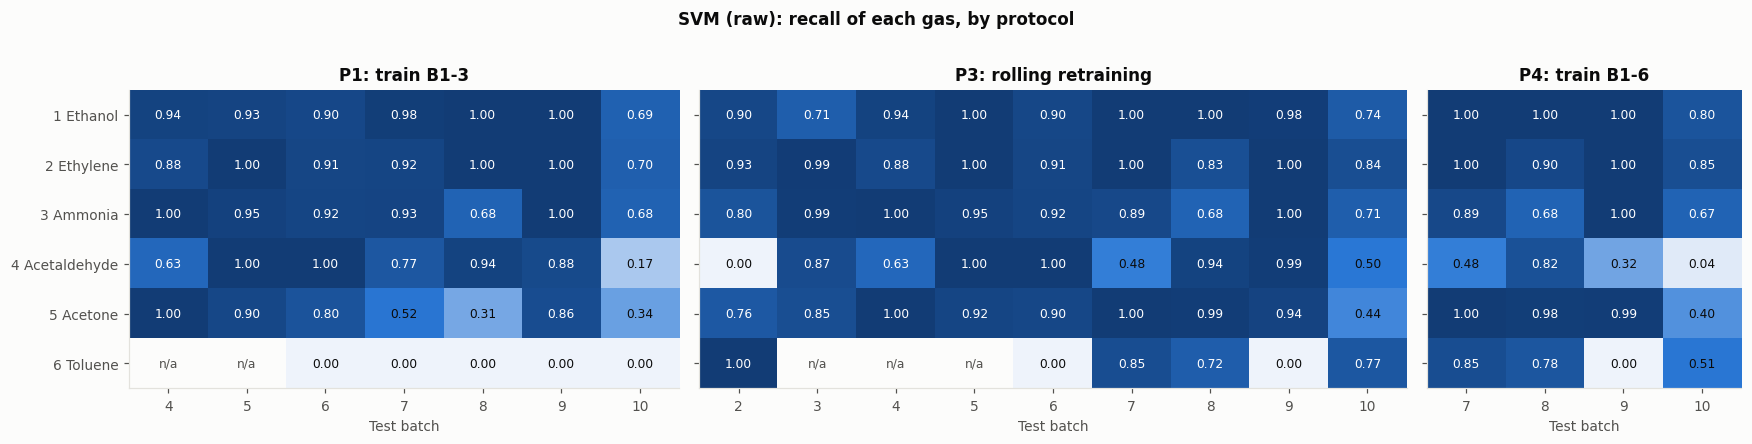

SVM (raw), pooled over test batches 7-10 (the same samples under all three protocols): recall / precision / F1 per gas


P1                      P3                      P4  \
               recall precision     f1 recall precision     f1 recall   
1 Ethanol       0.849     0.327  0.472  0.882     0.688  0.773  0.909   
2 Ethylene      0.829     0.951  0.886  0.927     0.803  0.860  0.929   
3 Ammonia       0.789     0.992  0.879  0.796     0.994  0.884  0.773   
4 Acetaldehyde  0.533     0.449  0.488  0.523     0.709  0.602  0.294   
5 Acetone       0.440     0.880  0.586  0.763     0.824  0.792  0.746   
6 Toluene       0.000       NaN  0.000  0.746     0.682  0.712  0.627   

                                 
               precision     f1  
1 Ethanol          0.515  0.657  
2 Ethylene         0.694  0.794  
3 Ammonia          0.999  0.871  
4 Acetaldehyde     0.966  0.451  
5 Acetone          0.816  0.779  
6 Toluene          0.680  0.653

In [3]:
def gas_recall(proto, model="SVM"):
    lo = LO[proto]; m = batch >= lo
    t = per_gas_table(y[m], DF[proto][KEY[proto](model)].to_numpy(), batch[m], list(range(lo, 11)))
    return t, t.pivot(index="gas", columns="batch", values="recall")
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [7, 9, 4]}, sharey=True); tabs = {}
for ax, (proto, title) in zip(axes, [("P1", "P1: train B1-3"), ("P3", "P3: rolling retraining"), ("P4", "P4: train B1-6")]):
    t, rec = gas_recall(proto); tabs[proto] = t
    ax.imshow(np.ma.masked_invalid(rec.values), cmap=SEQ, vmin=0, vmax=1, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(rec.shape[1])); ax.set_xticklabels(rec.columns); ax.set_yticks(range(6)); ax.set_yticklabels([f"{g} {GAS_NAMES[g]}" for g in rec.index]); ax.set_xlabel("Test batch")
    for i in range(6):
        for j in range(rec.shape[1]):
            v = rec.values[i, j]; ax.text(j, i, "n/a" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8, color=INK2 if np.isnan(v) else ("white" if v > 0.55 else INK))
    ax.set_title(title)
fig.suptitle("SVM (raw): recall of each gas, by protocol", y=1.02, fontsize=11, fontweight="bold"); fig.tight_layout(); fig.savefig(FIG / "43_per_gas_recall_by_protocol.png"); plt.show()

on7 = pd.concat({p: tabs[p][tabs[p].batch >= 7].groupby("gas").agg(recall=("true_positives", "sum"), support=("support", "sum"), predicted=("predicted", "sum")) for p in tabs}, axis=1)
rows = {}
for p in tabs:
    d = tabs[p][tabs[p].batch >= 7].groupby("gas").agg(tp=("true_positives", "sum"), s=("support", "sum"), pr=("predicted", "sum"))
    rows[p] = pd.DataFrame({"recall": d.tp / d.s, "precision": d.tp / d.pr.replace(0, np.nan), "f1": 2 * d.tp / (d.s + d.pr)})
perg = pd.concat(rows, axis=1); perg.index = [f"{g} {GAS_NAMES[g]}" for g in perg.index]; perg.to_csv(RES / "12_per_gas_B7-10_SVM.csv")
print("SVM (raw), pooled over test batches 7-10 (the same samples under all three protocols): recall / precision / F1 per gas"); display(perg.round(3))

## 2. Does having Toluene in training fix it? (all seven models, test batches 7-10)

Same test samples for every protocol: batches 7-10. **Toluene F1** and the overall **macro-F1** (mean over the four batches).

macro_F1               macro_F1_gases1to5                \
protocol                P1     P3     P4                 P1     P3     P4   
model                                                                       
SVM                  0.587  0.789  0.720              0.704  0.832  0.755   
kNN                  0.531  0.805  0.685              0.637  0.816  0.739   
Random Forest        0.367  0.745  0.548              0.441  0.773  0.605   
Gradient Boosting    0.328  0.673  0.576              0.393  0.703  0.589   
AdaBoost             0.333  0.507  0.495              0.399  0.572  0.555   
Naive Bayes          0.280  0.283  0.256              0.327  0.276  0.249   
Decision Tree        0.241  0.593  0.525              0.290  0.644  0.582   

                  toluene_recall                
protocol                      P1     P3     P4  
model                                           
SVM                        0.000  0.746  0.627  
kNN                        0.000  0.744  0.587  
Random Forest              0.000  0.602  0.356  
Gradient Boosting          0.001  0.580  0.586  
AdaBoost                   0.000  0.343  0.239  
Naive Bayes                0.054  0.653  0.609  
Decision Tree              0.000  0.389  0.284

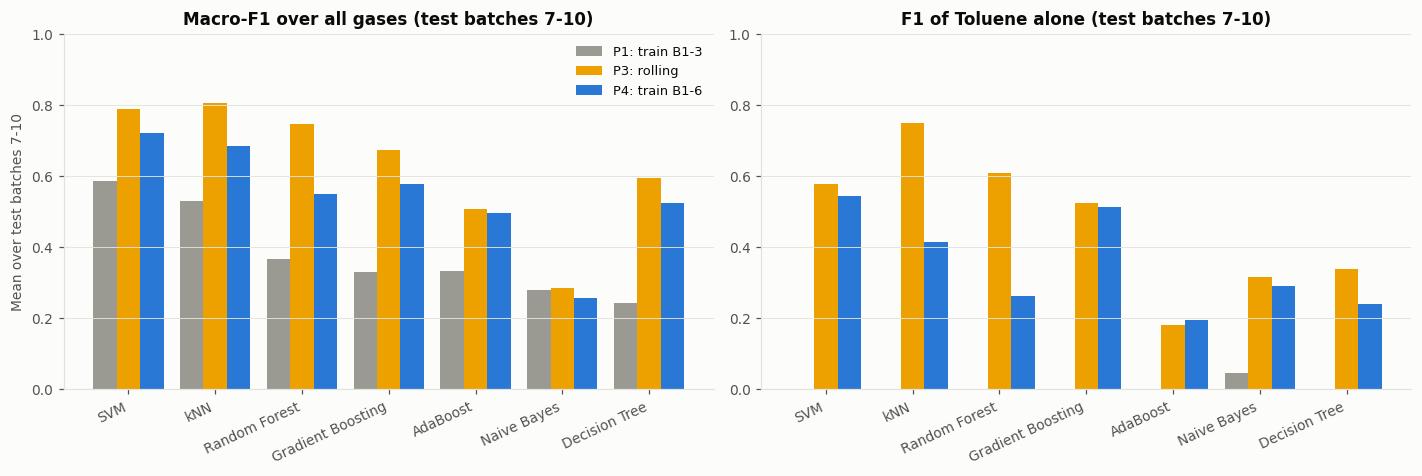

In [4]:
rows = []
for proto in ["P1", "P3", "P4"]:
    for m in MODELS:
        p = pred_on(proto, m, 7); t = per_gas_table(y7, p, b7, [7, 8, 9, 10])
        tol = t[t.gas == 6]; f15 = t[t.gas != 6].groupby("batch").f1.mean()
        rows.append({"protocol": proto, "model": m, "macro_F1": per_batch_f1(y7, p, b7, [7, 8, 9, 10]).mean(), "macro_F1_gases1to5": f15.mean(),
                     "toluene_recall": tol.true_positives.sum() / tol.support.sum(), "toluene_F1": tol.f1.mean()})
cmp = pd.DataFrame(rows); cmp.to_csv(RES / "12_models_by_protocol_B7-10.csv", index=False)
display(cmp.pivot(index="model", columns="protocol", values=["macro_F1", "macro_F1_gases1to5", "toluene_recall"]).loc[MODELS].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4)); xs = np.arange(len(MODELS)); w = 0.27; colr = {"P1": "#9a9992", "P3": SERIES[3], "P4": SERIES[0]}
for ax, (col, title) in zip(axes, [("macro_F1", "Macro-F1 over all gases"), ("toluene_F1", "F1 of Toluene alone")]):
    for j, proto in enumerate(["P1", "P3", "P4"]):
        d = cmp[cmp.protocol == proto].set_index("model").loc[MODELS, col]
        ax.bar(xs + (j - 1) * w, d.values, w, color=colr[proto], label={"P1": "P1: train B1-3", "P3": "P3: rolling", "P4": "P4: train B1-6"}[proto])
    ax.set_xticks(xs); ax.set_xticklabels(MODELS, rotation=25, ha="right"); ax.set_ylim(0, 1); ax.set_title(title + " (test batches 7-10)"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Mean over test batches 7-10"); axes[0].legend(frameon=False, fontsize=8.5, loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "44_toluene_by_protocol.png"); plt.show()

### Statistical check (SVM and Random Forest, P4 minus P1 on the same test batches 7-10)

Paired two-level bootstrap as in notebook 10. **Only four test batches are involved, so the intervals are necessarily wide.**

In [5]:
res = []
for m in ["SVM", "Random Forest"]:
    d = {"P4": pred_on("P4", m, 7), "P1": pred_on("P1", m, 7)}
    F, names = bootstrap_f1(y7, d, b7, [7, 8, 9, 10], n_boot=2000, seed=42); pt = {k: per_batch_f1(y7, d[k], b7, [7, 8, 9, 10]) for k in d}
    c = compare(F, names, "P4", "P1", pt)
    res.append({"comparison": f"{m} raw: P4 minus P1 (B7-10)", "diff": c["diff"], "two-level 95% CI": f"[{c['ci_two_level'][0]:+.3f}, {c['ci_two_level'][1]:+.3f}]", "P4 better on": f"{c['batches_A_better']}/4", "verdict": c["verdict"]})
res = pd.DataFrame(res); res.to_csv(RES / "12_p4_vs_p1_comparisons.csv", index=False); display(res.round(3))

,comparison,diff,two-level 95% CI,P4 better on,verdict
0,SVM raw: P4 minus P1 (B7-10),0.134,"[-0.013, +0.279]",3/4,suggestive
1,Random Forest raw: P4 minus P1 (B7-10),0.181,"[+0.070, +0.328]",4/4,clear


## 3. What is Toluene mistaken for?

Among the true Toluene samples of test batches 7-10 (SVM, scaling only): the share predicted as each gas.

In [6]:
conf = {}
for proto in ["P1", "P4"]:
    p = pred_on(proto, "SVM", 7)[y7 == 6]; conf[proto] = pd.Series({f"{g} {GAS_NAMES[g]}": float((p == g).mean()) for g in range(1, 7)})
conf = pd.DataFrame(conf); conf.to_csv(RES / "12_toluene_confusion_SVM.csv"); print(f"{int((y7 == 6).sum())} Toluene samples in batches 7-10"); display(conf.round(3))

1287 Toluene samples in batches 7-10


,P1,P4
1 Ethanol,0.693,0.228
2 Ethylene,0.000,0.107
3 Ammonia,0.000,0.000
4 Acetaldehyde,0.263,0.000
5 Acetone,0.044,0.037
6 Toluene,0.000,0.627


## 4. Does ignoring Toluene change the model ranking?

Rank correlation (Spearman) between the model order by **all-gas macro-F1** and by **macro-F1 over gases 1-5**, per protocol (test batches 7-10 for P1/P3/P4).

In [7]:
from scipy.stats import spearmanr
rk = []
for proto in ["P1", "P3", "P4"]:
    d = cmp[cmp.protocol == proto].set_index("model").loc[MODELS]
    rk.append({"protocol": proto, "Spearman rho (all gases vs gases 1-5)": spearmanr(d.macro_F1, d.macro_F1_gases1to5)[0], "best model, all gases": d.macro_F1.idxmax(), "best model, gases 1-5": d.macro_F1_gases1to5.idxmax()})
rk = pd.DataFrame(rk); rk.to_csv(RES / "12_ranking_with_without_toluene.csv", index=False); display(rk.round(3))

,protocol,Spearman rho (all gases vs gases 1-5),"best model, all gases","best model, gases 1-5"
0,P1,1.000,SVM,SVM
1,P3,0.964,kNN,SVM
2,P4,0.964,SVM,SVM


## 5. Learning curve: how many recent samples does the model need?

Training set = batches 1-3 + *n* samples from batch 6. Curves show the mean over test batches 7-10 and over five random draws; the band is the range over the draws.
Left to right: more samples added; x positions are the values n = 0, 5, 10, 25, 50, 100, 200, 467. **Toluene-only arm** vs **control arm** (random samples of any gas).

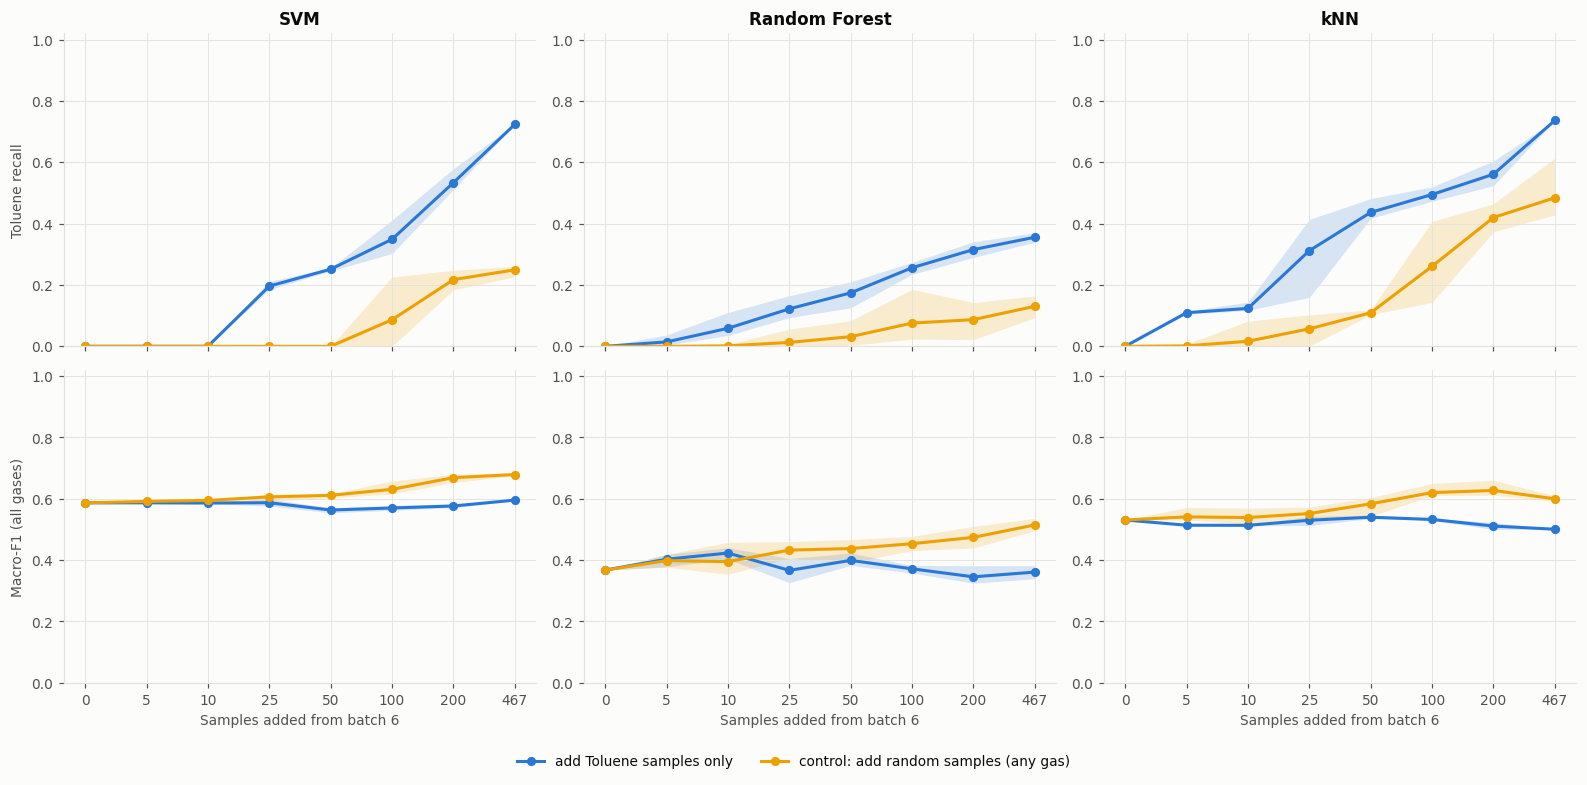

,model,arm,Toluene recall at n=0,at n=50,at n=467,smallest n with recall >= 0.5
0,SVM,toluene,0.0,0.252,0.724,200
1,SVM,random,0.0,0.000,0.250,never
2,Random Forest,toluene,0.0,0.174,0.356,never
3,Random Forest,random,0.0,0.032,0.131,never
4,kNN,toluene,0.0,0.437,0.736,200
5,kNN,random,0.0,0.109,0.484,never


In [8]:
per = lc.groupby(["model", "arm", "n", "seed"]).agg(toluene_recall=("toluene_recall", "mean"), macro_f1=("macro_f1", "mean"), macro_f1_gases1to5=("macro_f1_gases1to5", "mean"), tol_in_train=("toluene_in_train", "first")).reset_index()
agg = per.groupby(["model", "arm", "n"]).agg(toluene_recall=("toluene_recall", "mean"), tr_lo=("toluene_recall", "min"), tr_hi=("toluene_recall", "max"),
                                             macro_f1=("macro_f1", "mean"), mf_lo=("macro_f1", "min"), mf_hi=("macro_f1", "max"), macro_f1_gases1to5=("macro_f1_gases1to5", "mean"), toluene_in_train=("tol_in_train", "mean")).reset_index()
agg.to_csv(RES / "12_learning_curve_summary.csv", index=False)
armc = {"toluene": SERIES[0], "random": SERIES[3]}; xpos = {n: i for i, n in enumerate(N_GRID)}
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7), sharex=True)
for j, m in enumerate(["SVM", "Random Forest", "kNN"]):
    for i, (col, lo_, hi_, yl) in enumerate([("toluene_recall", "tr_lo", "tr_hi", "Toluene recall"), ("macro_f1", "mf_lo", "mf_hi", "Macro-F1 (all gases)")]):
        ax = axes[i, j]
        for arm, lab in [("toluene", "add Toluene samples only"), ("random", "control: add random samples (any gas)")]:
            d = agg[(agg.model == m) & (agg.arm == arm)].sort_values("n"); x = [xpos[n] for n in d.n]
            ax.fill_between(x, d[lo_], d[hi_], color=armc[arm], alpha=0.18, lw=0); ax.plot(x, d[col], color=armc[arm], marker="o", ms=5, lw=2, label=lab)
        ax.set_ylim(0, 1.02); ax.set_xticks(range(len(N_GRID))); ax.set_xticklabels(N_GRID)
        if i == 1: ax.set_xlabel("Samples added from batch 6")
        if j == 0: ax.set_ylabel(yl)
        if i == 0: ax.set_title(m)
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02)); fig.tight_layout(rect=(0, 0.03, 1, 1)); fig.savefig(FIG / "45_toluene_learning_curve.png"); plt.show()

need = []
for m in ["SVM", "Random Forest", "kNN"]:
    for arm in ["toluene", "random"]:
        d = agg[(agg.model == m) & (agg.arm == arm)].sort_values("n"); ok = d[d.toluene_recall >= 0.5]
        need.append({"model": m, "arm": arm, "Toluene recall at n=0": d.toluene_recall.iloc[0], "at n=50": float(d[d.n == 50].toluene_recall.iloc[0]), "at n=467": d.toluene_recall.iloc[-1],
                     "smallest n with recall >= 0.5": int(ok.n.iloc[0]) if len(ok) else "never"})
need = pd.DataFrame(need); need.to_csv(RES / "12_learning_curve_thresholds.csv", index=False); display(need.round(3))

## 6. Key takeaways

All models use default settings. Test batches 7-10 contain 1,287 Toluene samples. P1 = train on batches 1-3, P4 = train on batches 1-6, P3 = rolling retraining (all compared on the same test batches 7-10). Per-gas numbers are pooled over those batches.

1. **Under P1 the Toluene failure is total, and it contaminates the other gases.** The SVM never predicts Toluene (recall 0.000; 69.3% of the Toluene samples are called Ethanol, 26.3% Acetaldehyde, 4.4% Acetone). Those wrong calls wreck the *precision* of the gases that absorb them: Ethanol precision is only 0.327 (recall 0.849) and Acetaldehyde precision 0.449. So even the macro-F1 over gases 1-5 (0.704) stays well below its rolling-retraining value (0.832).
2. **With Toluene in training, it becomes learnable.** Under P4 the SVM recognises 62.7% of Toluene (precision 0.680, F1 0.653; 22.8% of Toluene is still called Ethanol), and under rolling retraining 74.6% (precision 0.682, F1 0.712). Macro-F1 on batches 7-10 rises from P1 to P4 to P3: SVM 0.587, 0.720, 0.789; kNN 0.531, 0.685, 0.805; Random Forest 0.367, 0.548, 0.745; Gradient Boosting 0.328, 0.576, 0.673; Naive Bayes stays poor (0.280, 0.256, 0.283). P4 minus P1: SVM +0.134 (two-level 95% CI -0.013 to +0.279, better on 3 of 4 batches, suggestive), Random Forest +0.181 (+0.070 to +0.328, 4 of 4, clear); only four test batches are involved. Part of the P4 gain comes from batches 4-6 being more recent, not only from Toluene. **Scarcity is not the whole story**: even with Toluene in training the SVM misses all of batch 9's Toluene (recall 0.00 under both P4 and P3, 101 samples), while batches 7, 8 and 10 are recognised at 0.85, 0.78 and 0.51 (P4) and 0.85, 0.72 and 0.77 (P3); that batch's Toluene has drifted away from what was seen in training.
3. **Ignoring Toluene does not change the model comparison.** Rank correlation between the model order by all-gas macro-F1 and by macro-F1 over gases 1-5 is 1.00 (P1) and 0.96 (P3, P4). SVM is best in P1 and P4 either way; under rolling retraining kNN is best with all gases (0.805 vs 0.789) and SVM without Toluene (0.832 vs 0.816). **The model rankings of the earlier notebooks are therefore not an artefact of the Toluene problem**, which was the main worry after notebook 06.
4. **How many recent samples are needed? Many, and the kind of sample matters.** Adding Toluene-only samples from batch 6 to the batch 1-3 training set (mean over test batches 7-10 and 5 random draws): Toluene recall of the SVM rises 0.00, 0.20, 0.25, 0.35, 0.53, 0.72 for 0, 25, 50, 100, 200, 467 added samples (kNN 0.00, 0.31, 0.44, 0.49, 0.56, 0.74); both reach 50% recall at about 200 Toluene samples, whereas the Random Forest never gets there (0.36 at 467).
5. **Targeted collection of the missing gas backfires; a representative recent sample helps more.** In the Toluene-only arm, overall macro-F1 stays flat (SVM 0.587 to 0.595 at 467 samples, dipping to 0.563 at 50) because the other gases suffer: macro-F1 over gases 1-5 falls from 0.704 to 0.640 (SVM), 0.441 to 0.378 (Random Forest) and 0.637 to 0.534 (kNN), while Toluene's share of the training set jumps from 2.4% to 14.6%. In the control arm (the same number of random samples of any gas from batch 6) macro-F1 rises steadily: SVM 0.587 to 0.631 (100 samples), 0.669 (200) and 0.679 (467); Random Forest 0.367 to 0.515 at 467; kNN 0.531 to 0.627 (200). The control reaches only 25% Toluene recall for the SVM at 467 samples (about 90 of them Toluene), yet it improves overall performance far more. **A small, representative recently labelled sample of all gases beats targeting the poorly recognised gas.**
6. **What changes for the earlier conclusions.** The P1 numbers should be read as "train on a period that barely contains Toluene": the Toluene failure is a data-availability problem on top of drift (Toluene is learnable once recent examples exist), and its collateral damage to other gases' precision explains part of the large P1 penalty. The ranking of models, the random-split illusion, and the negative results for tuning, mitigation and stacking do not depend on it.
7. **Caveats.** One source batch (batch 6) and test batches 7-10 adjacent to it, so the learning curve is optimistic about how well recent data transfers to later ones; default models; no confidence intervals on the learning curve (range over 5 random draws only); the control arm differs from the Toluene arm in both composition and the number of Toluene samples; the reason Acetaldehyde recall drops under P4 (0.533 to 0.294) was not investigated (batch 6 contains only 29 Acetaldehyde samples, which may shift the class balance).